# Market Risk Case

### 0.Libraries and data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# Load data
PROJECT=Path(".")
DATA=PROJECT/'data'
OUTPUT=PROJECT/'output'

counterparties=pd.read_excel(DATA/'Counterparties.xlsx')
Fx_rates=pd.read_excel(DATA/'FX_Rates.xlsx')
limits=pd.read_excel(DATA/'Limits.xlsx')
market_prices=pd.read_excel(DATA/'Market_Prices.xlsx')
trades=pd.read_excel(DATA/'Trades.xlsx')
yield_curves=pd.read_excel(DATA/'Yield_Curves.xlsx')


### 1. ETL

#### 1.1 Shape and data types

In [3]:
trades.shape
trades.dtypes

TradeID             int64
TraderID           object
CounterpartyID     object
Ticker             object
Quantity            int64
Currency           object
TradePrice        float64
TradeDate          object
dtype: object

#### 1.2 Duplicates

In [4]:
# There are no duplicates
trades.duplicated().sum()
trades[trades.duplicated()]

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate


#### 1.3 Missing values

In [5]:
# There 18 records missing the CounterpartyID. Then ask front office for them.
trades.isnull().sum()
trades[trades['CounterpartyID'].isnull()]

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02
1,1001,TR-004,NaN,SAP,-343,EUR,264.82,2026-07-10
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05
7,1007,TR-004,NaN,MSFT,-538,USD,236.52,2026-07-10
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09
11,1011,TR003,NaN,SAP,-473,EUR,243.43,2026-07-01
13,1013,TR-004,NaN,VOLV-B,-220,SEK,288.90,2026-07-08
15,1015,TR001,NaN,VOLV-B,-328,SEK,108.19,2026-07-05
16,1016,TR002,NaN,AAPL,-738,USD,210.98,2026-07-10
17,1017,TR003,NaN,NOVO-B,-232,DKK,209.28,2026-07-11


### 2. Data Cleaning

In [6]:
trades['TradeID'].is_unique

False

In [7]:
# TradeID=1005 is duplicated
trades[trades['TradeID'].duplicated()]
trades[trades['TradeID']==1005]

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08
40,1005,TR002,CP02,AAPL,999,USD,150.00,2026-07-05


In [8]:
# Replace TR-004 to TR004
trades['TraderID'].unique()
trades['TraderID']=trades['TraderID'].apply(lambda x: x.replace('-',''))

In [9]:
# Replace US$ to USD
trades['Currency'].unique()
trades['Currency']=trades['Currency'].apply(lambda x: x.replace('US$','USD'))

In [10]:
# Make sure all dates have the same format
trades['TradeDate']=pd.to_datetime(trades['TradeDate'],format='%Y-%m-%d')
market_prices['PriceDate']=pd.to_datetime(market_prices['PriceDate'],format='%Y-%m-%d')

In [11]:
# Make sure all prices are numeric
trades['TradePrice']=pd.to_numeric(trades['TradePrice'])

### 3. Merge

In [12]:
# trades&market_prices
df_master=trades.merge(market_prices,how='left',on='Ticker')
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290


In [13]:
# Add limits
df_master=df_master.merge(limits,how='left',on='TraderID')
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,LimitEUR
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,50000
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,70000
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500,50000
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120,80000
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500,60000
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180,50000
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310,70000
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,70000
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310,50000
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,50000


In [14]:
# Add counterparties
df_master=df_master.merge(counterparties,how='left',on='CounterpartyID')
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,LimitEUR,Name,Country
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,50000,NaN,NaN
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,70000,NaN,NaN
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500,50000,Atlas Fund,UK
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120,80000,NordBank,SE
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500,60000,NaN,NaN
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180,50000,Blue Capital,DE
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310,70000,Atlas Fund,UK
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,70000,NaN,NaN
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310,50000,NordBank,SE
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,50000,NaN,NaN


In [15]:
# Add Fx_rates
df_master=df_master.merge(Fx_rates,how='left',on='Currency')
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,LimitEUR,Name,Country,EUR_Rate
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,50000,NaN,NaN,1.000
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,70000,NaN,NaN,1.000
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500,50000,Atlas Fund,UK,0.134
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120,80000,NordBank,SE,1.000
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500,60000,NaN,NaN,0.134
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180,50000,Blue Capital,DE,0.860
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310,70000,Atlas Fund,UK,0.089
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,70000,NaN,NaN,0.860
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310,50000,NordBank,SE,0.860
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,50000,NaN,NaN,0.860


### 4. Calculations

- Local market value
- EUR market value
- Current market value using market prices
- Unrealized P&L

In [16]:
# Local market value
df_master['MarketValueLocal']=df_master['Quantity']*df_master['TradePrice']

In [17]:
# EUR market value
df_master['MarketValueEUR']=df_master['MarketValueLocal']*df_master['EUR_Rate']

In [18]:
# Current market value using market_prices
df_master['CurrentMarketValue']=df_master['Quantity']*df_master['Close']

In [19]:
# Unrealized P&L
df_master['UnrealizedPnL']=(df_master['Close']-df_master['TradePrice'])*df_master['Quantity']
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,LimitEUR,Name,Country,EUR_Rate,MarketValueLocal,MarketValueEUR,CurrentMarketValue,UnrealizedPnL
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,50000,NaN,NaN,1.000,199999.80,199999.80000,83160,-116839.80
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,70000,NaN,NaN,1.000,-90833.26,-90833.26000,-41160,49673.26
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500,50000,Atlas Fund,UK,0.134,41414.10,5549.48940,136500,95085.90
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120,80000,NordBank,SE,1.000,59122.56,59122.56000,53760,-5362.56
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500,60000,NaN,NaN,0.134,17489.79,2343.63186,153500,136010.21
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180,50000,Blue Capital,DE,0.860,40383.40,34729.72400,41400,1016.60
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310,70000,Atlas Fund,UK,0.089,-5184.90,-461.45610,-13020,-7835.10
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,70000,NaN,NaN,0.860,-127247.76,-109433.07360,-156020,-28772.24
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310,50000,NordBank,SE,0.860,-1062.18,-913.47480,-5580,-4517.82
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,50000,NaN,NaN,0.860,-240735.82,-207032.80520,-277820,-37084.18


### 5. Risk Analysis

In [20]:
# Total portfolio value (EUR)
total_portfolio_value=df_master['MarketValueEUR'].sum()
total_portfolio_value

-365790.07087999984

In [21]:
# Exposure by trader (EUR)
exposure_by_trader=df_master.groupby('TraderID')['MarketValueEUR'].sum()
exposure_by_trader

TraderID
TR001    -24477.55675
TR002    166189.82892
TR003   -152696.17686
TR004   -354806.16619
Name: MarketValueEUR, dtype: float64

In [22]:
# Exposure by counterparty(EUR)
exposure_by_counterparty=df_master.groupby('CounterpartyID')['MarketValueEUR'].sum()
exposure_by_counterparty

CounterpartyID
CP01    116309.87983
CP02    269352.49941
CP03   -372152.99546
Name: MarketValueEUR, dtype: float64

In [23]:
# Exposure by country(EUR)
exposure_by_country=df_master.groupby('Country')['MarketValueEUR'].sum()
exposure_by_country

Country
DE    269352.49941
SE    116309.87983
UK   -372152.99546
Name: MarketValueEUR, dtype: float64

In [24]:
# Exposure by currency
exposure_by_currency=df_master.groupby('Currency')['MarketValueLocal'].sum()
exposure_by_currency

Currency
DKK    651025.22
EUR    -32386.84
SEK    -40579.04
USD   -484917.53
Name: MarketValueLocal, dtype: float64

In [25]:
# Top 10 largest positions
df_master['abs_MarketValueEUR']=abs(df_master['MarketValueEUR'])
top_10=df_master.sort_values('abs_MarketValueEUR',ascending=False).head(10)
top_10

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,LimitEUR,Name,Country,EUR_Rate,MarketValueLocal,MarketValueEUR,CurrentMarketValue,UnrealizedPnL,abs_MarketValueEUR
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,50000,NaN,NaN,0.86,-240735.82,-207032.8052,-277820,-37084.18,207032.8052
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,50000,NaN,NaN,1.00,199999.80,199999.8000,83160,-116839.80,199999.8000
19,1019,TR001,CP03,SAP,-618,EUR,260.76,2026-07-02,2026-07-01,120,80000,Atlas Fund,UK,1.00,-161149.68,-161149.6800,-74160,86989.68,161149.6800
24,1024,TR004,CP03,AAPL,-691,USD,236.00,2026-07-04,2026-07-11,180,70000,Atlas Fund,UK,0.86,-163076.00,-140245.3600,-124380,38696.00,140245.3600
16,1016,TR002,NaN,AAPL,-738,USD,210.98,2026-07-10,2026-07-11,180,60000,NaN,NaN,0.86,-155703.24,-133904.7864,-132840,22863.24,133904.7864
40,1005,TR002,CP02,AAPL,999,USD,150.00,2026-07-05,2026-07-11,180,60000,Blue Capital,DE,0.86,149850.00,128871.0000,179820,29970.00,128871.0000
11,1011,TR003,NaN,SAP,-473,EUR,243.43,2026-07-01,2026-07-01,120,50000,NaN,NaN,1.00,-115142.39,-115142.3900,-56760,58382.39,115142.3900
36,1036,TR002,NaN,SAP,558,EUR,199.61,2026-07-06,2026-07-01,120,60000,NaN,NaN,1.00,111382.38,111382.3800,66960,-44422.38,111382.3800
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,70000,NaN,NaN,0.86,-127247.76,-109433.0736,-156020,-28772.24,109433.0736
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,70000,NaN,NaN,1.00,-90833.26,-90833.2600,-41160,49673.26,90833.2600


In [26]:
# Top 5 counterparties
top_counterparties=(df_master.groupby('CounterpartyID')['abs_MarketValueEUR'].sum()).sort_values(ascending=False)

### 6. Limit Monitoring

Limits are usually checked on the total exposure per trader, not trade by trade.
Limit= When the market value (EUR) by TraderID is greater than the limit.

- Which traders exceed their limits?
- By how much?

In [27]:
# Merge exposure_by_trader&limits
exposure_by_trader=exposure_by_trader.to_frame().merge(limits,how='left',on='TraderID')
exposure_by_trader

,TraderID,MarketValueEUR,LimitEUR
0,TR001,-24477.55675,80000
1,TR002,166189.82892,60000
2,TR003,-152696.17686,50000
3,TR004,-354806.16619,70000


In [28]:
# Breach
exposure_by_trader['Breach']=np.where(exposure_by_trader['MarketValueEUR']>exposure_by_trader['LimitEUR'],'YES','NO')
exposure_by_trader

,TraderID,MarketValueEUR,LimitEUR,Breach
0,TR001,-24477.55675,80000,NO
1,TR002,166189.82892,60000,YES
2,TR003,-152696.17686,50000,NO
3,TR004,-354806.16619,70000,NO


In [29]:
# Breach excess
exposure_by_trader['BreachExcess']=np.where((exposure_by_trader['MarketValueEUR']-exposure_by_trader['LimitEUR'])>0,exposure_by_trader['MarketValueEUR']-exposure_by_trader['LimitEUR'],0)
exposure_by_trader

,TraderID,MarketValueEUR,LimitEUR,Breach,BreachExcess
0,TR001,-24477.55675,80000,NO,0.00000
1,TR002,166189.82892,60000,YES,106189.82892
2,TR003,-152696.17686,50000,NO,0.00000
3,TR004,-354806.16619,70000,NO,0.00000


In [30]:
# Merge df_master&exposure_by_trader
df_master=df_master.merge(exposure_by_trader[['TraderID','Breach','BreachExcess']],how='left',on='TraderID')
df_master

,TradeID,TraderID,CounterpartyID,Ticker,Quantity,Currency,TradePrice,TradeDate,PriceDate,Close,...,Name,Country,EUR_Rate,MarketValueLocal,MarketValueEUR,CurrentMarketValue,UnrealizedPnL,abs_MarketValueEUR,Breach,BreachExcess
0,1000,TR003,NaN,SAP,693,EUR,288.60,2026-07-02,2026-07-01,120,...,NaN,NaN,1.000,199999.80,199999.80000,83160,-116839.80,199999.80000,NO,0.00000
1,1001,TR004,NaN,SAP,-343,EUR,264.82,2026-07-10,2026-07-01,120,...,NaN,NaN,1.000,-90833.26,-90833.26000,-41160,49673.26,90833.26000,NO,0.00000
2,1002,TR003,CP03,NOVO-B,273,DKK,151.70,2026-07-08,2026-07-11,500,...,Atlas Fund,UK,0.134,41414.10,5549.48940,136500,95085.90,5549.48940,NO,0.00000
3,1003,TR001,CP01,SAP,448,EUR,131.97,2026-07-03,2026-07-01,120,...,NordBank,SE,1.000,59122.56,59122.56000,53760,-5362.56,59122.56000,NO,0.00000
4,1004,TR002,NaN,NOVO-B,307,DKK,56.97,2026-07-05,2026-07-11,500,...,NaN,NaN,0.134,17489.79,2343.63186,153500,136010.21,2343.63186,YES,106189.82892
5,1005,TR003,CP02,AAPL,230,USD,175.58,2026-07-08,2026-07-11,180,...,Blue Capital,DE,0.860,40383.40,34729.72400,41400,1016.60,34729.72400,NO,0.00000
6,1006,TR004,CP03,VOLV-B,-42,SEK,123.45,2026-07-03,2026-07-11,310,...,Atlas Fund,UK,0.089,-5184.90,-461.45610,-13020,-7835.10,461.45610,NO,0.00000
7,1007,TR004,NaN,MSFT,-538,USD,236.52,2026-07-10,2026-07-11,290,...,NaN,NaN,0.860,-127247.76,-109433.07360,-156020,-28772.24,109433.07360,NO,0.00000
8,1008,TR003,CP01,VOLV-B,-18,USD,59.01,2026-07-09,2026-07-11,310,...,NordBank,SE,0.860,-1062.18,-913.47480,-5580,-4517.82,913.47480,NO,0.00000
9,1009,TR003,NaN,MSFT,-958,USD,251.29,2026-07-09,2026-07-11,290,...,NaN,NaN,0.860,-240735.82,-207032.80520,-277820,-37084.18,207032.80520,NO,0.00000


### 7. Market Data Validation

One market price is intentionally stale.

- Which asset?
- Why is it stale?
- What would you recommend as a risk analyst?

In [31]:
# SAP is stale because its PriceDate starts 10 days earlier than the other stocks
# This is a problem because imagine today is 2026-07-11, and we're calculating the firm's exposure.
# For AAPL: Current market price = today's price ✅
# For SAP:  We're using a price from 10 days ago ❌
# If SAP moved significantly during those 10 days, then: Market Value is wrong, P&L is wrong
market_prices

,Ticker,PriceDate,Close
0,AAPL,2026-07-11,180
1,MSFT,2026-07-11,290
2,SAP,2026-07-01,120
3,NOVO-B,2026-07-11,500
4,VOLV-B,2026-07-11,310


In [32]:
# Check
report_date = pd.Timestamp("2026-07-11")

market_prices["PriceDate"] = pd.to_datetime(market_prices["PriceDate"])

market_prices["DaysOld"] = (
    report_date - market_prices["PriceDate"]
).dt.days

In [33]:
# Flag it
stale_prices = market_prices[
    market_prices["DaysOld"] > 1
]

### 8. Final Report

In [34]:
# Clean trades
trades.to_excel(OUTPUT/ 'Clean_Trades.xlsx',index=False)

In [35]:
# Risk_Report
df_master.to_excel(OUTPUT/ 'Risk_Report.xlsx',index=False)

### 9. Visualization

#### 9.1 Pivot table

In [36]:
# A pivot table showing exposure by Trader × Currency
pivot=df_master.pivot_table(values='MarketValueLocal',index='TraderID',columns='Currency',aggfunc='sum',fill_value=0)
pivot

Currency,DKK,EUR,SEK,USD
TraderID,,,,
TR001,389634.32,-73454.77,-36334.67,0.00
TR002,247350.58,111382.38,0.00,25188.92
TR003,11.71,20518.81,0.00,-201414.60
TR004,14028.61,-90833.26,-4244.37,-308691.85


#### 9.2 Bar chart

Text(0, 0.5, 'Exposure (EUR)')

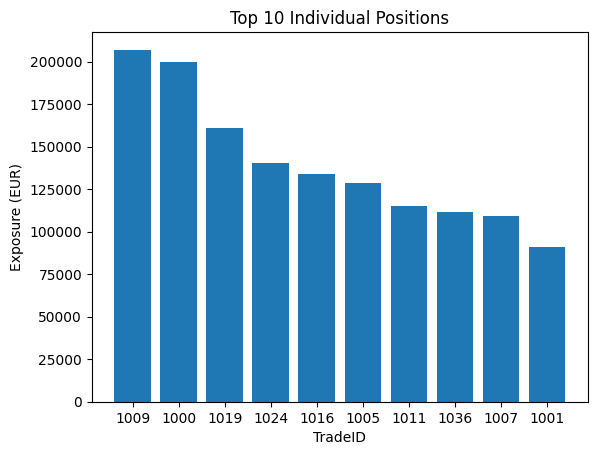

In [37]:
# A bar chart of the top 10 individual exposures
plt.bar(top_10['TradeID'].astype(str),top_10['abs_MarketValueEUR'])
plt.title('Top 10 Individual Positions')
plt.xlabel('TradeID')
plt.ylabel('Exposure (EUR)')

Text(0, 0.5, 'Exposure (EUR)')

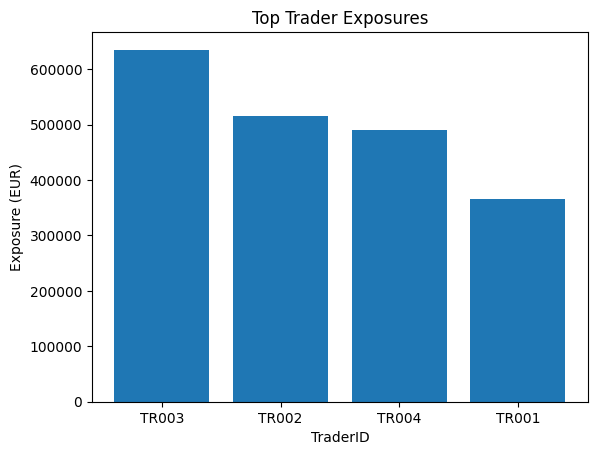

In [38]:
# Top 10 exposures by trader
top_traders=df_master.groupby('TraderID')['abs_MarketValueEUR'].sum().sort_values(ascending=False).head(10)

plt.bar(top_traders.index,top_traders.values)
plt.title('Top Trader Exposures')
plt.xlabel('TraderID')
plt.ylabel('Exposure (EUR)')